Installing missing package: scikit-learn...
Running Optimized Multimodal Pipeline on device: cuda
File 'dataset.csv' not found. Generating expanded synthetic dataset...

   STARTING HYBRID 5-FOLD STRATIFIED CV PIPELINE   

--- FOLD 1/5 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Fold 1 | Epoch 01/04 | Loss: 1.1646 | Val Acc: 0.3333 | Val Macro-F1: 0.1667
Fold 1 | Epoch 02/04 | Loss: 1.0802 | Val Acc: 0.5000 | Val Macro-F1: 0.4127
Fold 1 | Epoch 03/04 | Loss: 1.0503 | Val Acc: 0.6667 | Val Macro-F1: 0.5556
Fold 1 | Epoch 04/04 | Loss: 1.0156 | Val Acc: 0.6667 | Val Macro-F1: 0.5556

--- FOLD 2/5 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Fold 2 | Epoch 01/04 | Loss: 1.1034 | Val Acc: 0.6667 | Val Macro-F1: 0.5556
Fold 2 | Epoch 02/04 | Loss: 1.0000 | Val Acc: 0.8333 | Val Macro-F1: 0.8222
Fold 2 | Epoch 03/04 | Loss: 0.9307 | Val Acc: 1.0000 | Val Macro-F1: 1.0000
Fold 2 | Epoch 04/04 | Loss: 0.8877 | Val Acc: 1.0000 | Val Macro-F1: 1.0000

--- FOLD 3/5 ---


...

Fold 3 | Epoch 01/04 | Loss: 1.1049 | Val Acc: 0.6667 | Val Macro-F1: 0.5556
Fold 3 | Epoch 02/04 | Loss: 0.9843 | Val Acc: 0.8333 | Val Macro-F1: 0.8222
Fold 3 | Epoch 03/04 | Loss: 0.9649 | Val Acc: 0.8333 | Val Macro-F1: 0.8222
Fold 3 | Epoch 04/04 | Loss: 0.8800 | Val Acc: 0.8333 | Val Macro-F1: 0.8222

--- FOLD 4/5 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Fold 4 | Epoch 01/04 | Loss: 1.0828 | Val Acc: 0.6667 | Val Macro-F1: 0.5556
Fold 4 | Epoch 02/04 | Loss: 0.9869 | Val Acc: 0.6667 | Val Macro-F1: 0.5556
Fold 4 | Epoch 03/04 | Loss: 0.9137 | Val Acc: 0.8333 | Val Macro-F1: 0.8222
Fold 4 | Epoch 04/04 | Loss: 0.8489 | Val Acc: 0.8333 | Val Macro-F1: 0.8222

--- FOLD 5/5 ---


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Fold 5 | Epoch 01/04 | Loss: 1.0900 | Val Acc: 0.6667 | Val Macro-F1: 0.5556
Fold 5 | Epoch 02/04 | Loss: 0.9762 | Val Acc: 0.6667 | Val Macro-F1: 0.5556
Fold 5 | Epoch 03/04 | Loss: 0.8744 | Val Acc: 0.8333 | Val Macro-F1: 0.8222
Fold 5 | Epoch 04/04 | Loss: 0.8225 | Val Acc: 0.8333 | Val Macro-F1: 0.8222

     SUMMARY: HYBRID 5-FOLD CROSS-VALIDATION RESULTS     
Accuracy        : 0.8333 ± 0.1054
Precision       : 0.8333 ± 0.1721
Recall          : 0.8333 ± 0.1054
Macro_f1        : 0.8044 ± 0.1422
Weighted_f1     : 0.8044 ± 0.1422
Roc_auc         : 0.9833 ± 0.0333


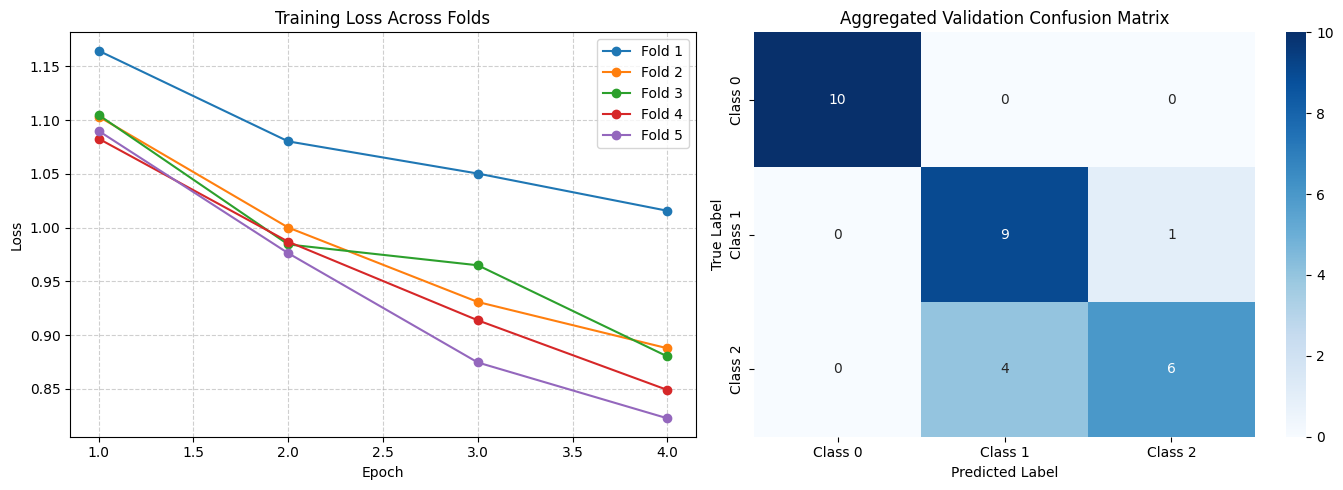

In [8]:
import sys
import subprocess

required_packages = [
    "torch", "transformers", "tree-sitter", "tree-sitter-python", 
    "numpy", "pandas", "scikit-learn", "matplotlib", "seaborn"
]
for pkg in required_packages:
    try:
        __import__(pkg.replace("-", "_"))
    except ImportError:
        print(f"Installing missing package: {pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", pkg])

import os
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup, logging
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, 
    f1_score, roc_auc_score, confusion_matrix
)
import tree_sitter
import tree_sitter_python as tspython

# Suppress verbose weights warnings from Hugging Face
logging.set_verbosity_error()

# Initialize Tree-Sitter Parser for Code DFG Extraction
PY_LANGUAGE = tree_sitter.Language(tspython.language())
parser = tree_sitter.Parser(PY_LANGUAGE)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Running Optimized Multimodal Pipeline on device: {DEVICE}")

# ==========================================
# 2. DFG Extraction & Input Processing
# ==========================================
def extract_variables_and_dfg(code_bytes):
    """Parses code into AST to extract variable tokens and DFG relationship edges."""
    tree = parser.parse(code_bytes)
    root = tree.root_node
    variables, dfg_edges = [], []
    
    def traverse(node):
        if node.type == 'identifier':
            var_name = code_bytes[node.start_byte:node.end_byte].decode('utf-8')
            var_idx = len(variables)
            variables.append((var_name, node.start_byte, node.end_byte))
            for prev_idx, (p_name, _, _) in enumerate(variables[:-1]):
                if p_name == var_name:
                    dfg_edges.append((prev_idx, var_idx))
        for child in node.children:
            traverse(child)
            
    traverse(root)
    return variables, dfg_edges

def build_graphcodebert_inputs(code_str, tokenizer, max_length=512):
    """Generates GraphCodeBERT input token IDs and 2D additive graph attention masks."""
    code_bytes = bytes(str(code_str), "utf-8")
    vars_list, dfg_edges = extract_variables_and_dfg(code_bytes)
    
    code_tokens = tokenizer.tokenize(str(code_str))
    var_tokens = [v[0] for v in vars_list]
    
    max_code_len = max_length - len(var_tokens) - 3
    code_tokens = code_tokens[:max_code_len]
    
    tokens = [tokenizer.cls_token] + code_tokens + [tokenizer.sep_token] + var_tokens + [tokenizer.sep_token]
    input_ids = tokenizer.convert_tokens_to_ids(tokens)
    
    code_len = len(code_tokens) + 2
    var_start_idx = code_len
    seq_len = len(input_ids)
    
    binary_mask = np.zeros((seq_len, seq_len), dtype=np.float32)
    binary_mask[:code_len, :code_len] = 1.0
    
    for v_idx in range(len(var_tokens)):
        binary_mask[var_start_idx + v_idx, var_start_idx + v_idx] = 1.0
        
    for src, tgt in dfg_edges:
        if src < len(var_tokens) and tgt < len(var_tokens):
            binary_mask[var_start_idx + tgt, var_start_idx + src] = 1.0
            binary_mask[var_start_idx + src, var_start_idx + tgt] = 1.0

    additive_mask = (1.0 - binary_mask) * -10000.0
    return input_ids, additive_mask

# ==========================================
# 3. Dataset & Collate Function
# ==========================================
class HybridMultimodalDataset(Dataset):
    def __init__(self, code_samples, tabular_features, labels, tokenizer):
        self.code_samples = list(code_samples)
        self.tabular_features = np.array(tabular_features, dtype=np.float32)
        self.labels = list(labels)
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.code_samples)

    def __getitem__(self, idx):
        input_ids, additive_mask = build_graphcodebert_inputs(
            self.code_samples[idx], self.tokenizer
        )
        return {
            'input_ids': input_ids,
            'additive_mask': additive_mask,
            'tabular_features': self.tabular_features[idx],
            'label': self.labels[idx]
        }

def collate_fn(batch):
    max_len = max(len(item['input_ids']) for item in batch)
    batch_size = len(batch)
    
    padded_input_ids = torch.zeros((batch_size, max_len), dtype=torch.long)
    padded_masks = torch.full((batch_size, 1, max_len, max_len), -10000.0, dtype=torch.float32)
    tabular_features = torch.tensor(np.array([item['tabular_features'] for item in batch]), dtype=torch.float32)
    labels = torch.tensor([item['label'] for item in batch], dtype=torch.long)
    
    for i, item in enumerate(batch):
        seq_len = len(item['input_ids'])
        padded_input_ids[i, :seq_len] = torch.tensor(item['input_ids'], dtype=torch.long)
        mask_2d = torch.tensor(item['additive_mask'], dtype=torch.float32)
        padded_masks[i, 0, :seq_len, :seq_len] = mask_2d

    return {
        'input_ids': padded_input_ids.to(DEVICE),
        'attention_mask': padded_masks.to(DEVICE),
        'tabular_features': tabular_features.to(DEVICE),
        'labels': labels.to(DEVICE)
    }

# ==========================================
# 4. Multimodal Model Architecture
# ==========================================
class HybridGraphCodeBERTClassifier(nn.Module):
    def __init__(self, tabular_dim, num_classes=3, model_name="microsoft/graphcodebert-base", dropout_rate=0.2):
        super().__init__()
        self.encoder = AutoModel.from_pretrained(model_name)
        text_hidden_size = self.encoder.config.hidden_size
        
        self.tabular_mlp = nn.Sequential(
            nn.Linear(tabular_dim, 64),
            nn.LayerNorm(64),
            nn.ReLU(),
            nn.Dropout(dropout_rate)
        )
        
        combined_dim = text_hidden_size + 64
        self.classifier = nn.Sequential(
            nn.Linear(combined_dim, 256),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(256, num_classes)
        )
        
    def forward(self, input_ids, attention_mask, tabular_features):
        outputs = self.encoder(input_ids=input_ids, attention_mask=attention_mask)
        cls_embedding = outputs.last_hidden_state[:, 0, :]
        tab_embedding = self.tabular_mlp(tabular_features)
        fused_features = torch.cat((cls_embedding, tab_embedding), dim=1)
        return self.classifier(fused_features)

# ==========================================
# 5. Training & Evaluation Engine
# ==========================================
def train_epoch(model, dataloader, optimizer, criterion, scheduler):
    model.train()
    total_loss = 0.0
    for batch in dataloader:
        optimizer.zero_grad()
        logits = model(batch['input_ids'], batch['attention_mask'], batch['tabular_features'])
        loss = criterion(logits, batch['labels'])
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
    return total_loss / max(1, len(dataloader))

def evaluate_metrics(model, dataloader):
    model.eval()
    all_preds, all_labels, all_probs = [], [], []
    
    with torch.no_grad():
        for batch in dataloader:
            logits = model(batch['input_ids'], batch['attention_mask'], batch['tabular_features'])
            probs = torch.softmax(logits, dim=-1)
            preds = torch.argmax(probs, dim=-1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(batch['labels'].cpu().numpy())
            all_probs.extend(probs.cpu().numpy())
            
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)
    all_probs = np.array(all_probs)
    
    acc = accuracy_score(all_labels, all_preds)
    macro_prec = precision_score(all_labels, all_preds, average='macro', zero_division=0)
    macro_rec = recall_score(all_labels, all_preds, average='macro', zero_division=0)
    macro_f1 = f1_score(all_labels, all_preds, average='macro', zero_division=0)
    weighted_f1 = f1_score(all_labels, all_preds, average='weighted', zero_division=0)
    
    try:
        roc_auc = roc_auc_score(all_labels, all_probs, multi_class='ovr', average='macro')
    except Exception:
        roc_auc = 0.0

    return {
        "accuracy": acc,
        "precision": macro_prec,
        "recall": macro_rec,
        "macro_f1": macro_f1,
        "weighted_f1": weighted_f1,
        "roc_auc": roc_auc,
        "true_labels": all_labels,
        "pred_labels": all_preds
    }

# ==========================================
# 6. Plotting Utilities
# ==========================================
def plot_cv_results(fold_histories, aggregate_cm, num_classes):
    """Generates training loss curves and dynamic confusion matrix visualizations."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Plot Loss Curves across Folds
    for fold, history in fold_histories.items():
        axes[0].plot(range(1, len(history) + 1), history, marker='o', label=f'Fold {fold}')
    axes[0].set_title("Training Loss Across Folds")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].grid(True, linestyle='--', alpha=0.6)
    axes[0].legend()

    # Plot Aggregate Confusion Matrix
    sns.heatmap(
        aggregate_cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
        xticklabels=[f'Class {i}' for i in range(num_classes)],
        yticklabels=[f'Class {i}' for i in range(num_classes)]
    )
    axes[1].set_title("Aggregated Validation Confusion Matrix")
    axes[1].set_xlabel("Predicted Label")
    axes[1].set_ylabel("True Label")

    plt.tight_layout()
    plt.savefig("cv_performance_summary.png", dpi=300)
    plt.show()

# ==========================================
# 7. Execution Engine
# ==========================================
def run_hybrid_stratified_kfold(
    csv_path="dataset.csv", 
    code_col="code", 
    tabular_cols=None, 
    label_col="label", 
    requested_splits=5, 
    epochs=4, 
    batch_size=4, 
    lr=2e-5,
    checkpoint_dir="./checkpoints"
):
    os.makedirs(checkpoint_dir, exist_ok=True)
    if tabular_cols is None:
        tabular_cols = ["entropy", "file_size_kb", "num_api_calls"]

    try:
        df = pd.read_csv(csv_path)
        print(f"Loaded CSV successfully with {len(df)} records.")
    except Exception:
        print(f"File '{csv_path}' not found. Generating expanded synthetic dataset...")
        
        # 10 samples per class (30 total) for smoother fold distributions
        code_templates = [
            ("def add(a, b):\n return a + b", 0), ("def mul(x, y):\n return x * y", 0),
            ("def sub(a, b):\n return a - b", 0), ("def div(a, b):\n return a / b if b != 0 else 0", 0),
            ("def mod(m, n):\n return m % n", 0), ("def square(v):\n return v ** 2", 0),
            ("def cube(v):\n return v ** 3", 0), ("def abs_val(n):\n return abs(n)", 0),
            ("def negate(x):\n return -x", 0), ("def double(x):\n return x * 2", 0),
            
            ("def read_file(p):\n return open(p).read()", 1), ("def write_file(p, d):\n open(p, 'w').write(d)", 1),
            ("def log_data(p, m):\n open(p, 'a').write(m)", 1), ("def check_path(p):\n return os.path.exists(p)", 1),
            ("def fetch_meta(p):\n return os.stat(p)", 1), ("def create_dir(d):\n os.makedirs(d, exist_ok=True)", 1),
            ("def list_files(d):\n return os.listdir(d)", 1), ("def read_lines(p):\n return open(p).readlines()", 1),
            ("def get_size(p):\n return os.path.getsize(p)", 1), ("def copy_file(s, d):\n shutil.copy(s, d)", 1),
            
            ("def delete_sys(t):\n os.remove(t)", 2), ("def wipe_disk(p):\n shutil.rmtree(p)", 2),
            ("def kill_proc(pid):\n os.kill(pid, 9)", 2), ("def execute_cmd(c):\n subprocess.call(c, shell=True)", 2),
            ("def zero_drive(d):\n os.system('dd if=/dev/zero of=' + d)", 2), ("def stop_sec():\n os.system('netsh set state off')", 2),
            ("def inject_code(p):\n win32process.CreateRemoteThread(p)", 2), ("def dump_mem(p):\n os.system('pmdump ' + str(p))", 2),
            ("def corrupt_reg(k):\n winreg.DeleteKey(k)", 2), ("def encrypt_files(d):\n cryptography.fernet.encrypt(d)", 2)
        ]
        
        synthetic_data = []
        for code, label in code_templates:
            if label == 0:
                entropy = np.random.uniform(1.8, 2.5)
                size = np.random.uniform(5, 20)
                apis = np.random.randint(1, 5)
            elif label == 1:
                entropy = np.random.uniform(4.0, 5.0)
                size = np.random.uniform(80, 150)
                apis = np.random.randint(10, 20)
            else:
                entropy = np.random.uniform(7.5, 8.0)
                size = np.random.uniform(350, 600)
                apis = np.random.randint(70, 120)
                
            synthetic_data.append({
                "code": code, "entropy": entropy, "file_size_kb": size, 
                "num_api_calls": apis, "label": label
            })
        df = pd.DataFrame(synthetic_data)

    X_code = df[code_col].values
    X_tab = df[tabular_cols].values
    y = df[label_col].values
    num_classes = len(np.unique(y))
    tabular_dim = X_tab.shape[1]

    min_class_samples = np.min(np.bincount(y))
    n_splits = min(requested_splits, min_class_samples)

    model_name = "microsoft/graphcodebert-base"
    tokenizer = AutoTokenizer.from_pretrained(model_name)
    skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
    
    fold_metrics = {"accuracy": [], "precision": [], "recall": [], "macro_f1": [], "weighted_f1": [], "roc_auc": []}
    fold_histories = {}
    aggregate_cm = np.zeros((num_classes, num_classes), dtype=int)
    
    print("\n" + "="*65)
    print(f"   STARTING HYBRID {n_splits}-FOLD STRATIFIED CV PIPELINE   ")
    print("="*65)

    for fold, (train_idx, val_idx) in enumerate(skf.split(X_code, y), 1):
        print(f"\n--- FOLD {fold}/{n_splits} ---")
        
        # Fit scaler ONLY on training fold to prevent data leakage
        scaler = StandardScaler()
        X_tab_train = scaler.fit_transform(X_tab[train_idx])
        X_tab_val = scaler.transform(X_tab[val_idx])
        
        train_ds = HybridMultimodalDataset(X_code[train_idx], X_tab_train, y[train_idx], tokenizer)
        val_ds = HybridMultimodalDataset(X_code[val_idx], X_tab_val, y[val_idx], tokenizer)
        
        train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, collate_fn=collate_fn, drop_last=len(train_ds) > batch_size)
        val_loader = DataLoader(val_ds, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
        
        model = HybridGraphCodeBERTClassifier(tabular_dim=tabular_dim, num_classes=num_classes, model_name=model_name).to(DEVICE)
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.01)
        scheduler = get_linear_schedule_with_warmup(
            optimizer, num_warmup_steps=0, num_training_steps=max(1, len(train_loader)) * epochs
        )
        
        best_f1 = -1.0
        best_model_path = os.path.join(checkpoint_dir, f"best_model_fold{fold}.pt")
        epoch_losses = []
        
        for epoch in range(1, epochs + 1):
            train_loss = train_epoch(model, train_loader, optimizer, criterion, scheduler)
            epoch_losses.append(train_loss)
            val_m = evaluate_metrics(model, val_loader)
            print(f"Fold {fold} | Epoch {epoch:02d}/{epochs:02d} | Loss: {train_loss:.4f} | Val Acc: {val_m['accuracy']:.4f} | Val Macro-F1: {val_m['macro_f1']:.4f}")
            
            if val_m['macro_f1'] > best_f1:
                best_f1 = val_m['macro_f1']
                torch.save({
                    'epoch': epoch,
                    'model_state_dict': model.state_dict(),
                    'optimizer_state_dict': optimizer.state_dict(),
                    'macro_f1': best_f1,
                    'accuracy': val_m['accuracy']
                }, best_model_path)
                
        fold_histories[fold] = epoch_losses
        checkpoint = torch.load(best_model_path)
        model.load_state_dict(checkpoint['model_state_dict'])
        final_fold_m = evaluate_metrics(model, val_loader)
        
        # Accumulate confusion matrix
        fold_cm = confusion_matrix(final_fold_m['true_labels'], final_fold_m['pred_labels'], labels=list(range(num_classes)))
        aggregate_cm += fold_cm
        
        for key in fold_metrics:
            fold_metrics[key].append(final_fold_m[key])

    print("\n" + "="*65)
    print(f"     SUMMARY: HYBRID {n_splits}-FOLD CROSS-VALIDATION RESULTS     ")
    print("="*65)
    for k, values in fold_metrics.items():
        print(f"{k.capitalize():<15} : {np.mean(values):.4f} ± {np.std(values):.4f}")
    print("="*65)

    # Plot visual analytics
    plot_cv_results(fold_histories, aggregate_cm, num_classes)

if __name__ == "__main__":
    run_hybrid_stratified_kfold(
        csv_path="dataset.csv", 
        code_col="code", 
        tabular_cols=["entropy", "file_size_kb", "num_api_calls"],
        label_col="label", 
        requested_splits=5, 
        epochs=4, 
        batch_size=4
    )